In [3]:
import numpy as np
from pandas import read_csv, DataFrame
from fastccm import PairwiseCCM, utils as fastccm_utils
from time import perf_counter

df = read_csv("../data/Fly80XY_norm_1061.csv")

E = 7
sample = 50
pLibSizes = [10, 20, 80, 90]
tau = 1
Tp = 0
seed = 1

columns = [c for c in df.columns if c != "index"]
libSizes = [int(len(df) * p / 100) for p in pLibSizes]

# Build E-dimensional delay embeddings for each source variable.
embeddings_X = [
    np.array(
        fastccm_utils.embed(df[c].to_numpy()[:, None], E=E, tau=tau)[0],
        copy=True,
        order="C",
    )
    for c in columns
]

embeddings_Y = [
    np.array(df[c].to_numpy()[:, None], copy=True, order="C")
    for c in columns
]

ccm = PairwiseCCM(device="cpu", memory_budget_gb=3)
ccm_matrices = {}

t0 = perf_counter()

for i, libSize in enumerate(libSizes):
    trial_scores = []

    for t in range(sample):
        scores = ccm.score_matrix(
            X_emb=embeddings_X,
            Y_emb=embeddings_Y,
            library_size=libSize,
            sample_size=None,
            exclusion_window=0,
            tp=Tp,
            method="simplex",
            seed=seed + t,
            clean_after=(i == len(libSizes) - 1 and t == sample - 1),
        )
        trial_scores.append(scores[0])

    ccm_matrices[libSize] = DataFrame(
        np.mean(trial_scores, axis=0),
        index=columns,
        columns=columns,
    )

elapsed = perf_counter() - t0

print("libSizes:", libSizes)
print(f"elapsed: {elapsed:.3f}s")

display(ccm_matrices[libSizes[0]].iloc[:5, :5])
display(ccm_matrices[libSizes[-1]].iloc[:5, :5])


libSizes: [106, 212, 848, 954]
elapsed: 14.170s


,TS1,TS2,TS3,TS4,TS5
TS1,0.991040,0.977283,0.966402,0.973147,0.946492
TS2,0.948771,0.988879,0.940028,0.972638,0.933576
TS3,0.956442,0.965049,0.985186,0.967434,0.933672
TS4,0.945648,0.972260,0.944700,0.985625,0.934951
TS5,0.932923,0.951841,0.932042,0.952315,0.982973


,TS1,TS2,TS3,TS4,TS5
TS1,0.998613,0.985353,0.978248,0.982021,0.963515
TS2,0.977530,0.998319,0.962168,0.986982,0.962291
TS3,0.972581,0.972200,0.996985,0.976548,0.958874
TS4,0.972127,0.983848,0.963527,0.997256,0.962877
TS5,0.954839,0.971543,0.958051,0.970404,0.997641


,LibSize,FastCCM,pyEDM
0,106,0.696592,0.696836
1,212,0.708514,0.706984
2,848,0.732947,0.731861
3,954,0.735000,0.734657
4,1061,0.737051,0.737050


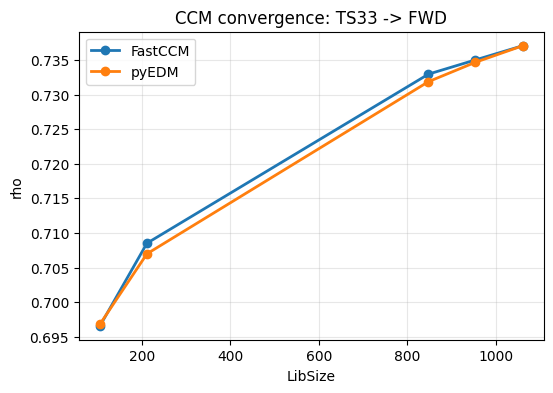

In [4]:
import numpy as np
from pandas import read_csv, DataFrame
from matplotlib import pyplot as plt
from fastccm import PairwiseCCM, utils as fastccm_utils
from pyEDM import CCM

df = read_csv("../data/Fly80XY_norm_1061.csv")

# Pick any pair you want to compare.
source = "TS33"
target = "FWD"

E = 7
sample = 50
pLibSizes = [10, 20, 80, 90, 100]
tau = 1
Tp = 0
seed = 3

libSizes = [int(len(df) * p / 100) for p in pLibSizes]

# FastCCM: embed the source manifold, keep the target scalar.
X_emb = [
    np.array(
        fastccm_utils.embed(df[source].to_numpy()[:, None], E=E, tau=tau)[0],
        copy=True,
        order="C",
    )
]
Y_emb = [
    np.array(df[target].to_numpy()[:, None], copy=True, order="C")
]

ccm = PairwiseCCM(device="cpu", memory_budget_gb=3)
fast_rho = []
for i, libSize in enumerate(libSizes):
    vals = []
    for t in range(sample):
        scores = ccm.score_matrix(
            X_emb=X_emb,
            Y_emb=Y_emb,
            library_size=libSize,
            sample_size=None,
            exclusion_window=0,
            tp=Tp,
            method="simplex",
            seed=seed + t,
            clean_after=(i == len(libSizes) - 1 and t == sample - 1),
        )
        vals.append(scores[0, 0, 0])
    fast_rho.append(np.mean(vals))


# pyEDM CCM on the same pair and same parameters.
pyedm_df = CCM(
    dataFrame=df,
    columns=source,
    target=target,
    libSizes=libSizes,
    sample=sample,
    E=E,
    Tp=Tp,
    tau=-tau,         
    exclusionRadius=0,
    seed=seed,
    noTime=False,
)

pyedm_rho = pyedm_df[f"{source}:{target}"].to_numpy()

compare_df = DataFrame(
    {
        "LibSize": libSizes,
        "FastCCM": fast_rho,
        "pyEDM": pyedm_rho,
    }
)

display(compare_df)

ax = compare_df.plot(
    x="LibSize",
    y=["FastCCM", "pyEDM"],
    marker="o",
    linewidth=2,
    figsize=(6, 4),
    title=f"CCM convergence: {source} -> {target}",
)
ax.set_ylabel("rho")
ax.grid(True, alpha=0.3)
plt.show()
